In [35]:
import pickle
from pathlib import Path

saved_path = Path("/Users/michaelfinch/CA1-interneuron-GLM/optuna_param_pickles")

all_pickles = {}

for pkl_file in saved_path.glob("*.pkl"):   # only .pkl files
    with open(pkl_file, "rb") as f:
        all_pickles[pkl_file.name] = pickle.load(f)

print(f"Loaded {len(all_pickles)} pickles")


Loaded 133 pickles


save_path = "/Users/michaelfinch/CA1-interneuron-GLM/optuna_param_pickles/animal_3_best_2.pkl"
with open(save_path, 'rb') as f:
    saved_data = pickle.load(f)

saved_data

In [43]:
import re
from collections import defaultdict

# Compile regex once for efficiency: matches animal_#_best_#.pkl
pattern = re.compile(r"^animal_(\d+)_best_(\d+)\.pkl$")

by_animal = defaultdict(dict)

for fname, pdata in all_pickles.items():
    match = pattern.match(fname)
    if match:
        animal_id = f"animal_{match.group(1)}"
        by_animal[animal_id][fname] = pdata

# Example: all pickles for animal_3
print(by_animal["animal_4"].keys())


dict_keys(['animal_4_best_6.pkl', 'animal_4_best_7.pkl', 'animal_4_best_5.pkl', 'animal_4_best_4.pkl', 'animal_4_best_0.pkl', 'animal_4_best_2.pkl'])


In [47]:
import re
from collections import defaultdict

# Matches any filename that contains this prefix pattern
pattern_lognormal = re.compile(
    r"^(animal_\d+_ec_param_search_animal_\d+_idx\d+_lognormal)"
)

by_animal_lognormal = defaultdict(dict)

for fname, pdata in all_pickles.items():
    match = pattern_lognormal.match(fname)
    if match:
        # extract animal ID from the match
        animal_id = match.group(1).split("_")[0] + "_" + match.group(1).split("_")[1]
        # keep original filename as the key
        by_animal_lognormal[animal_id][fname] = pdata

# Example: all lognormal pickles for animal_3
print(by_animal_lognormal["animal_3"].keys())


dict_keys(['animal_3_ec_param_search_animal_3_idx3_lognormal_job34709196_arr3_20250911_003841.pkl', 'animal_3_ec_param_search_animal_3_idx4_lognormal_job34709197_arr4_20250911_003841.pkl', 'animal_3_ec_param_search_animal_3_idx2_lognormal_job34709195_arr2_20250911_003841.pkl', 'animal_3_ec_param_search_animal_3_idx1_lognormal_job34709194_arr1_20250911_003841.pkl', 'animal_3_ec_param_search_animal_3_idx6_lognormal_job34709166_arr6_20250911_003838.pkl', 'animal_3_ec_param_search_animal_3_idx5_lognormal_job34709198_arr5_20250911_003838.pkl', 'animal_3_ec_param_search_animal_3_idx0_lognormal_job34709193_arr0_20250911_003841.pkl'])


In [48]:
import matplotlib.pyplot as plt
pickled_data = by_animal["animal_3"]

tau_dict = {}
threshold_dict = {}
weights_mean_dict = {}
weights_std_dict = {}
best_value_dict = {}
f12_active_dict = {}
frac_active_dict = {}
mean_total_dict = {}
mse_frac_dict = {}
mse_total_dict = {}
pen_12only_dict = {}
pen_sparsity_dict = {}
violations_dict = {}

for idx, optimization in enumerate(pickled_data):
    pickled_data_opti = pickled_data[optimization]
    print(pickled_data_opti)
    tau_dict[f"optimization_{idx}"] = pickled_data["best_params"]["tau_ms"]
    threshold_dict[f"optimization_{idx}"] = pickled_data["best_params"]["dend_threshold"]
    weights_std_dict[f"optimization_{idx}"] = pickled_data["best_params"]["weights_std"]
    best_value_dict[f"optimization_{idx}"] = pickled_data_opti["best_params"]["best_value"]
    f12_active_dict[f"optimization_{idx}"] = pickled_data_opti["best_metrics"]["f12_active"]
    frac_active_dict[f"optimization_{idx}"] = pickled_data_opti["best_metrics"]["frac_active"]
    mean_total_dict[f"optimization_{idx}"] =pickled_data_opti["best_metrics"]["mean_total"]
    mse_frac_dict[f"optimization_{idx}"] =pickled_data_opti["best_metrics"]["mse_frac"]
    mse_total_dict[f"optimization_{idx}"] =pickled_data_opti["best_metrics"]["mse_total"]

    pen_12only_dict[f"optimization_{idx}"] =pickled_data_opti["best_metrics"]["pen_12only"]
    pen_sparsity_dict[f"optimization_{idx}"] =pickled_data_opti["best_metrics"]["pen_sparsity"]
    violations_dict[f"optimization_{idx}"] =pickled_data_opti["best_metrics"]["violations"]

def scatter_from_dict(xdict, ydict, xlabel, ylabel, title):
    keys = [k for k in xdict if k in ydict and xdict[k] is not None and ydict[k] is not None]
    if not keys:
        print(f"[warn] No data to plot for: {title}")
        return
    x = [xdict[k] for k in keys]
    y = [ydict[k] for k in keys]

    plt.figure()
    plt.scatter(x, y)
    for k, xi, yi in zip(keys, x, y):
        plt.annotate(k, (xi, yi), textcoords="offset points", xytext=(5, 5), fontsize=8)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ---- core hyperparam vs objective ----
scatter_from_dict(tau_dict, best_value_dict, "tau_ms", "best objective", "tau_ms vs best objective")
scatter_from_dict(threshold_dict, best_value_dict, "dend_threshold", "best objective", "threshold vs best objective")
scatter_from_dict(weights_mean_dict, best_value_dict, "weights_mean", "best objective", "weights_mean vs best objective")
scatter_from_dict(weights_std_dict, best_value_dict, "weights_std", "best objective", "weights_std vs best objective")

# ---- a couple of metric views ----
scatter_from_dict(tau_dict, f12_active_dict, "tau_ms", "f12_active", "tau_ms vs f12_active")
scatter_from_dict(tau_dict, frac_active_dict, "tau_ms", "frac_active", "tau_ms vs frac_active")
scatter_from_dict(threshold_dict, mean_total_dict, "dend_threshold", "mean_total", "threshold vs mean_total")


# with open(pickled_data,'rb') as f:
#     pickled_dict = pickle.load(f)
#     print(pickled_dict)

{'best_params': {'tau_ms': 133.63175441372994, 'dend_threshold': -53.51632661472516, 'weights_mean': 0.9229500828533879, 'weights_std': 0.42433606320452333}, 'best_value': 282.3439689451796, 'animal': 'animal_3', 'best_metrics': {'f12_active': 1.0, 'frac_active': 0.278, 'mean_total': 28.2, 'mse_frac': 0.1030009451795841, 'mse_total': 282.24, 'pen_12only': 0.0, 'pen_sparsity': 0.00048399999999999843, 'violations': 0.0}, 'best_trial_number': 44}


KeyError: 'best_params'

In [49]:
from pathlib import Path
import pandas as pd

def best_of_each_animal(by_animal: dict) -> pd.DataFrame:
    """
    by_animal: {"animal_3": { "animal_3_best_0.pkl": payload, ...}, ...}
    Returns a DataFrame with the best (lowest) best_value per animal and the source pickle.
    """
    rows = []
    for animal, payloads in by_animal.items():
        best_name = None
        best_val = None
        best_params = {}
        weight_dist = None

        for fname, payload in payloads.items():
            val = payload.get("best_value")
            if val is None:
                continue
            if (best_val is None) or (val < best_val):
                best_val = float(val)
                best_name = fname
                params = payload.get("best_params", payload) or {}
                best_params = {
                    "tau_ms":        params.get("tau_ms"),
                    "dend_threshold":params.get("dend_threshold"),
                    "weights_mean":  params.get("weights_mean"),
                    "weights_std":   params.get("weights_std"),
                }
                weight_dist = payload.get("weight_dist")  # present if you saved it

        if best_name is not None:
            rows.append({
                "animal": animal,
                "best_value": best_val,
                "pickle": best_name,
                "tau_ms": best_params.get("tau_ms"),
                "dend_threshold": best_params.get("dend_threshold"),
                "weights_mean": best_params.get("weights_mean"),
                "weights_std": best_params.get("weights_std"),
                "weight_dist": weight_dist
            })

    df = pd.DataFrame(rows).sort_values(["animal"]).reset_index(drop=True)
    return df

# ---- usage ----
best_df_lognormal = best_of_each_animal(by_animal_lognormal)
print(best_df_lognormal.to_string(index=False))

if not best_df_lognormal.empty:
    overall_best = best_df_lognormal.loc[best_df_lognormal["best_value"].idxmin()]
    print("\nOverall best:")
    print(overall_best.to_string())



  animal  best_value                                                                                pickle     tau_ms  dend_threshold  weights_mean  weights_std weight_dist
animal_1    0.191407 animal_1_ec_param_search_animal_1_idx1_lognormal_job34688168_arr1_20250909_233806.pkl  46.474272      -66.133852      0.519112     0.126173   lognormal
animal_2   64.209437 animal_2_ec_param_search_animal_2_idx2_lognormal_job34709189_arr2_20250911_003841.pkl 113.831589      -66.280185      0.234987     0.165060   lognormal
animal_3   10.376623 animal_3_ec_param_search_animal_3_idx0_lognormal_job34709193_arr0_20250911_003841.pkl 164.316502      -66.006976      0.188010     0.120674   lognormal
animal_4  302.972701 animal_4_ec_param_search_animal_4_idx1_lognormal_job34709200_arr1_20250911_003838.pkl 168.533980      -66.553216      0.266669     0.334604   lognormal
animal_5   14.573863 animal_5_ec_param_search_animal_5_idx3_lognormal_job34709384_arr3_20250911_004237.pkl 199.759815      -66.937890  

In [50]:
import re
from pathlib import Path
import pandas as pd

BEST_RE = re.compile(r"^animal_(\d+)_best_\d+\.pkl$")

def best_of_each_animal_best_only(by_animal: dict) -> pd.DataFrame:
    """
    by_animal: {"animal_3": { "animal_3_best_0.pkl": payload, ...}, ...}
    Returns a DataFrame with the best (lowest) best_value per animal,
    using only files that match animal_<num>_best_<num>.pkl.
    """
    rows = []
    for animal, payloads in by_animal.items():
        best_name = None
        best_val = None
        best_params = {}

        # consider only the "best_*" architecture
        candidates = [
            (fname, payload)
            for fname, payload in payloads.items()
            if BEST_RE.match(Path(fname).name)
        ]

        for fname, payload in candidates:
            val = payload.get("best_value")
            if val is None:
                continue
            if (best_val is None) or (float(val) < best_val):
                best_val = float(val)
                best_name = Path(fname).name
                params = payload.get("best_params", payload) or {}
                best_params = {
                    "tau_ms":         params.get("tau_ms"),
                    "dend_threshold": params.get("dend_threshold"),
                    "weights_mean":   params.get("weights_mean"),
                    "weights_std":    params.get("weights_std"),
                }

        if best_name is not None:
            rows.append({
                "animal": animal,
                "best_value": best_val,
                "pickle": best_name,
                **best_params
            })

    df = pd.DataFrame(rows).sort_values(["animal"]).reset_index(drop=True)
    return df



# ---- usage ----
best_df = best_of_each_animal_best_only(by_animal)
print(best_df.to_string(index=False))

if not best_df.empty:
    overall_best = best_df.loc[best_df["best_value"].idxmin()]
    print("\nOverall best:")
    print(overall_best.to_string())


  animal   best_value              pickle     tau_ms  dend_threshold  weights_mean  weights_std
animal_2 1.115735e+03 animal_2_best_1.pkl 199.569045      -46.347043      0.860506     0.750475
animal_3 2.823440e+02 animal_3_best_2.pkl 133.631754      -53.516327      0.922950     0.424336
animal_4 1.000202e+07 animal_4_best_6.pkl 191.418097      -35.053554      0.770845     0.418341
animal_5 1.000202e+07 animal_5_best_0.pkl  92.493206      -37.184639      0.262991     0.388341
animal_6 1.354540e+03 animal_6_best_0.pkl 144.970396      -52.495562      0.996379     0.534686
animal_7 1.000202e+07 animal_7_best_1.pkl 193.445826      -53.976282      0.863061     0.900067

Overall best:
animal                       animal_3
best_value                 282.343969
pickle            animal_3_best_2.pkl
tau_ms                     133.631754
dend_threshold             -53.516327
weights_mean                  0.92295
weights_std                  0.424336


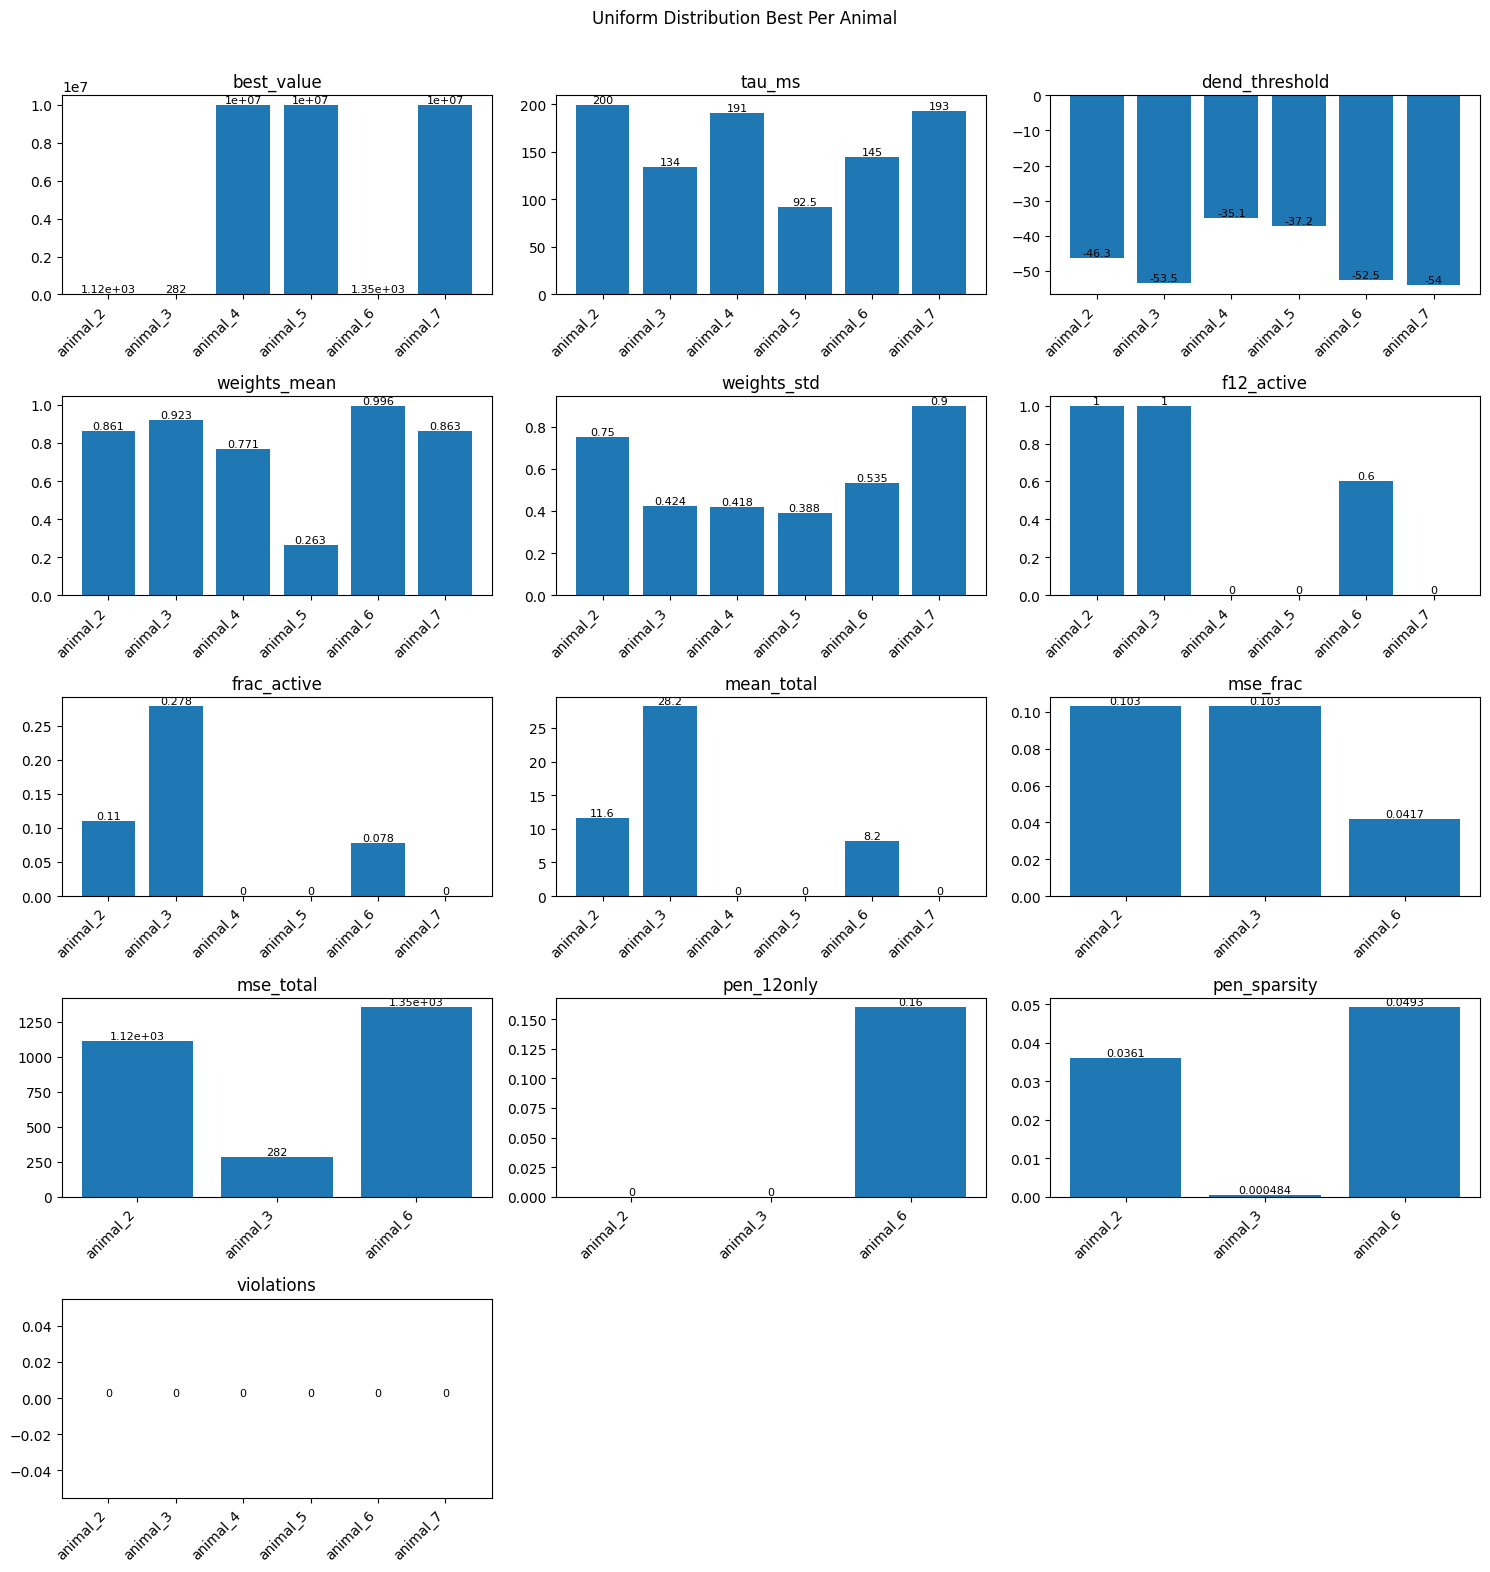

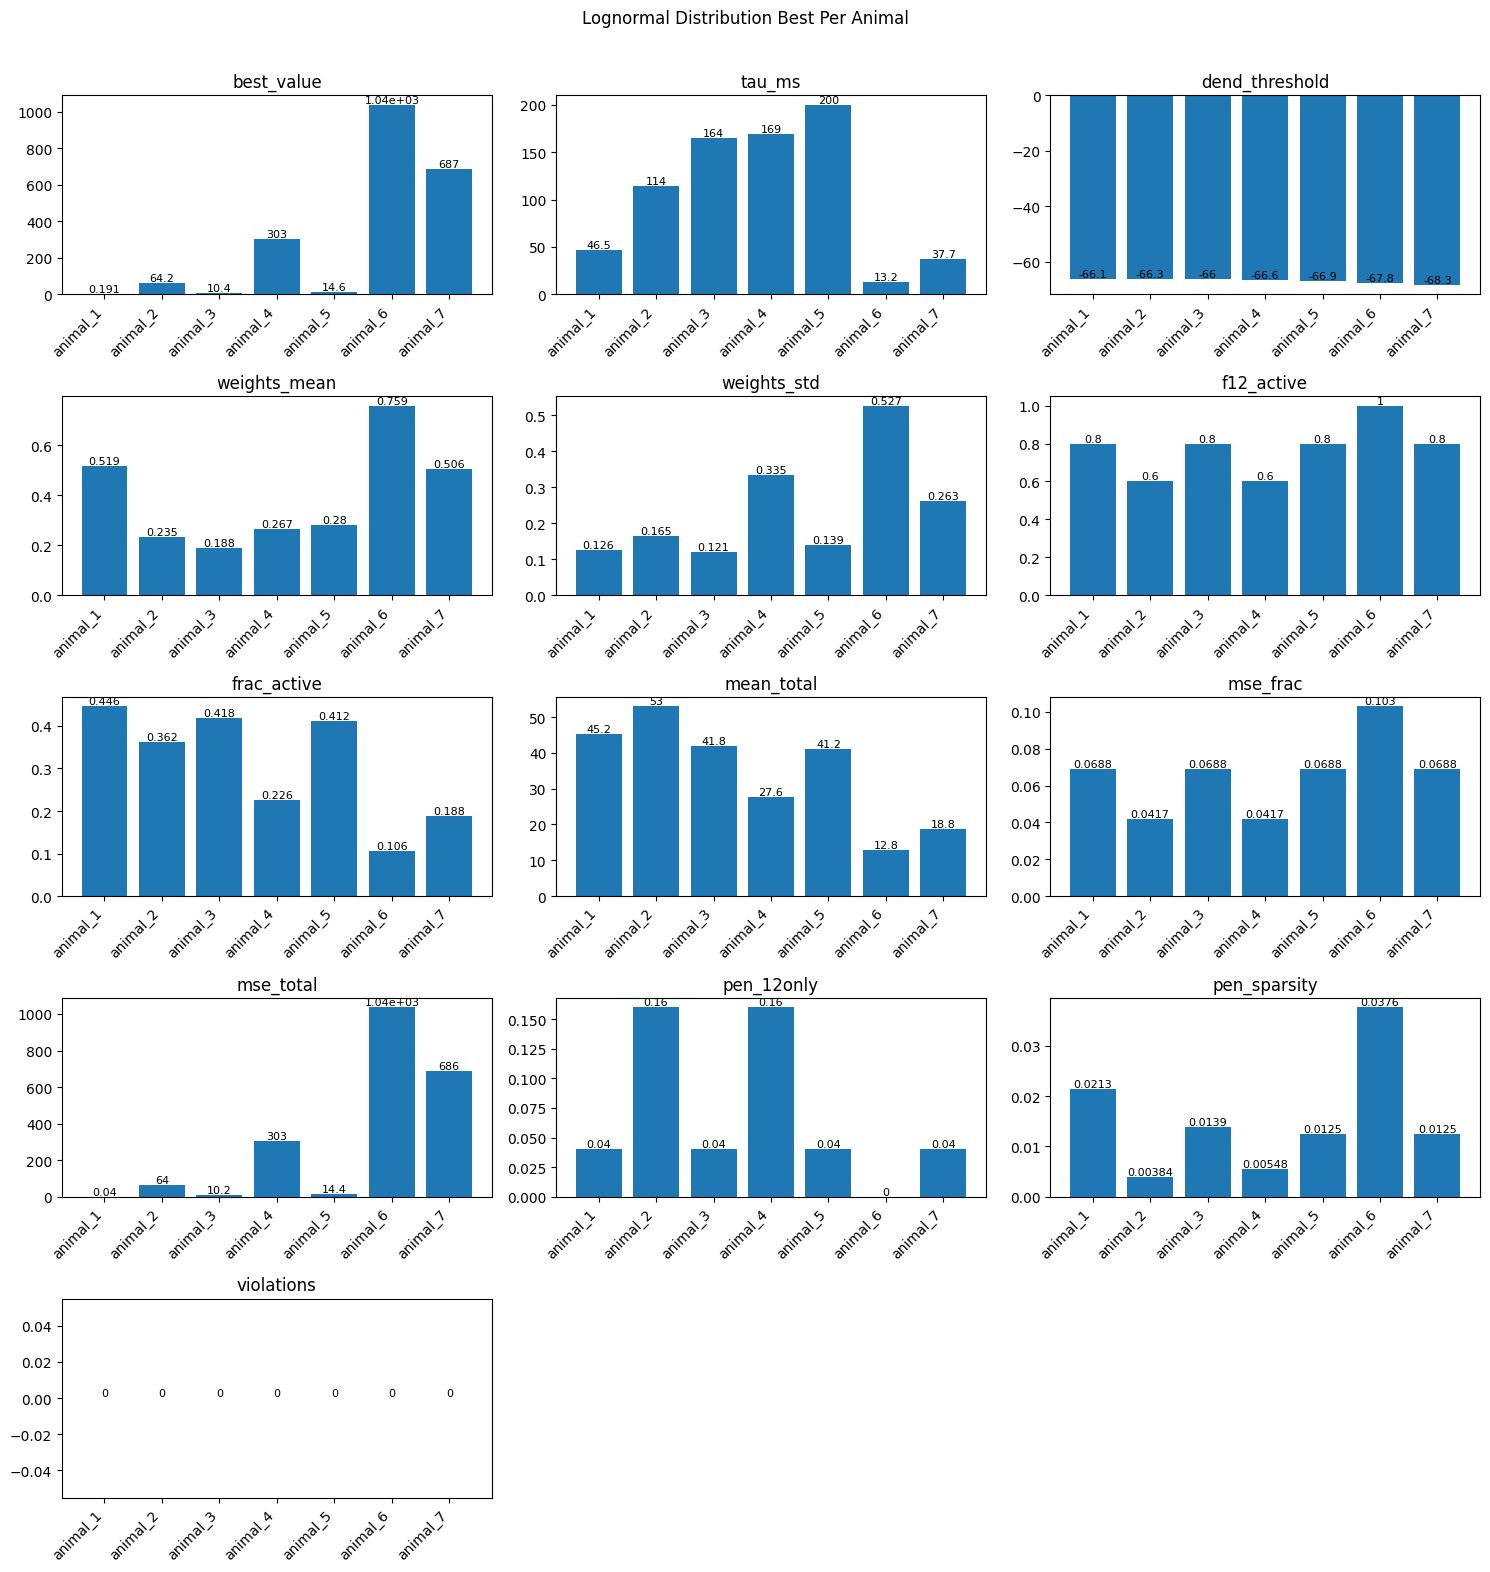

In [51]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_best_across_animals(by_animal, best_df, title):
    rows = []
    for r in best_df.itertuples(index=False):
        animal = r.animal
        fname  = str(r.pickle)
        payload = by_animal[animal][fname]
        params  = payload.get("best_params", payload) or {}
        metrics = payload.get("best_metrics", {}) or {}
        rows.append({
            "animal": animal,
            "pickle": fname,
            "best_value": payload.get("best_value"),
            "tau_ms": params.get("tau_ms"),
            "dend_threshold": params.get("dend_threshold"),
            "weights_mean": params.get("weights_mean"),
            "weights_std": params.get("weights_std"),
            "f12_active": metrics.get("f12_active"),
            "frac_active": metrics.get("frac_active"),
            "mean_total": metrics.get("mean_total"),
            "mse_frac": metrics.get("mse_frac"),
            "mse_total": metrics.get("mse_total"),
            "pen_12only": metrics.get("pen_12only"),
            "pen_sparsity": metrics.get("pen_sparsity"),
            "violations": metrics.get("violations"),
        })
    if not rows:
        print("[warn] no winners found")
        return

    df = pd.DataFrame(rows).set_index("animal").sort_index()

    cols = [
        "best_value", "tau_ms", "dend_threshold", "weights_mean", "weights_std",
        "f12_active", "frac_active", "mean_total", "mse_frac", "mse_total",
        "pen_12only", "pen_sparsity", "violations"
    ]
    cols = [c for c in cols if c in df.columns and df[c].notna().any()]

    n = len(cols)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.2*nrows), squeeze=False)
    fig.suptitle(f"{title} Best Per Animal")

    for ax, col in zip(axes.flat, cols):
        s = df[col].dropna()
        x = range(len(s))
        ax.bar(x, s.values)
        ax.set_title(col)
        ax.set_xticks(list(x))
        ax.set_xticklabels(s.index, rotation=45, ha="right")
        for i, y in enumerate(s.values):
            ax.text(i, y, f"{y:.3g}", ha="center", va="bottom", fontsize=8)

    for ax in axes.flat[len(cols):]:
        fig.delaxes(ax)

    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# use it:
plot_best_across_animals(by_animal, best_df, title="Uniform Distribution")
plot_best_across_animals(by_animal_lognormal, best_df_lognormal, title="Lognormal Distribution")



In [25]:
by_animal['animal_3']

{'animal_3_best_2.pkl': {'best_params': {'tau_ms': 133.63175441372994,
   'dend_threshold': -53.51632661472516,
   'weights_mean': 0.9229500828533879,
   'weights_std': 0.42433606320452333},
  'best_value': 282.3439689451796,
  'animal': 'animal_3',
  'best_metrics': {'f12_active': 1.0,
   'frac_active': 0.278,
   'mean_total': 28.2,
   'mse_frac': 0.1030009451795841,
   'mse_total': 282.24,
   'pen_12only': 0.0,
   'pen_sparsity': 0.00048399999999999843,
   'violations': 0.0},
  'best_trial_number': 44},
 'animal_3_best_3.pkl': {'best_params': {'tau_ms': 167.8623644835883,
   'dend_threshold': -51.04138626362193,
   'weights_mean': 0.8918737739934279,
   'weights_std': 0.24730527652050222},
  'best_value': 1883.9230607712666,
  'animal': 'animal_3',
  'best_metrics': {'f12_active': 0.6,
   'frac_active': 0.016,
   'mean_total': 1.6,
   'mse_frac': 0.04174877126654065,
   'mse_total': 1883.56,
   'pen_12only': 0.16000000000000003,
   'pen_sparsity': 0.08065599999999999,
   'violations'

In [ ]:


def plot_pickled_metrics(pickled_data: dict, title: str | None = None, sort_labels: bool = True)


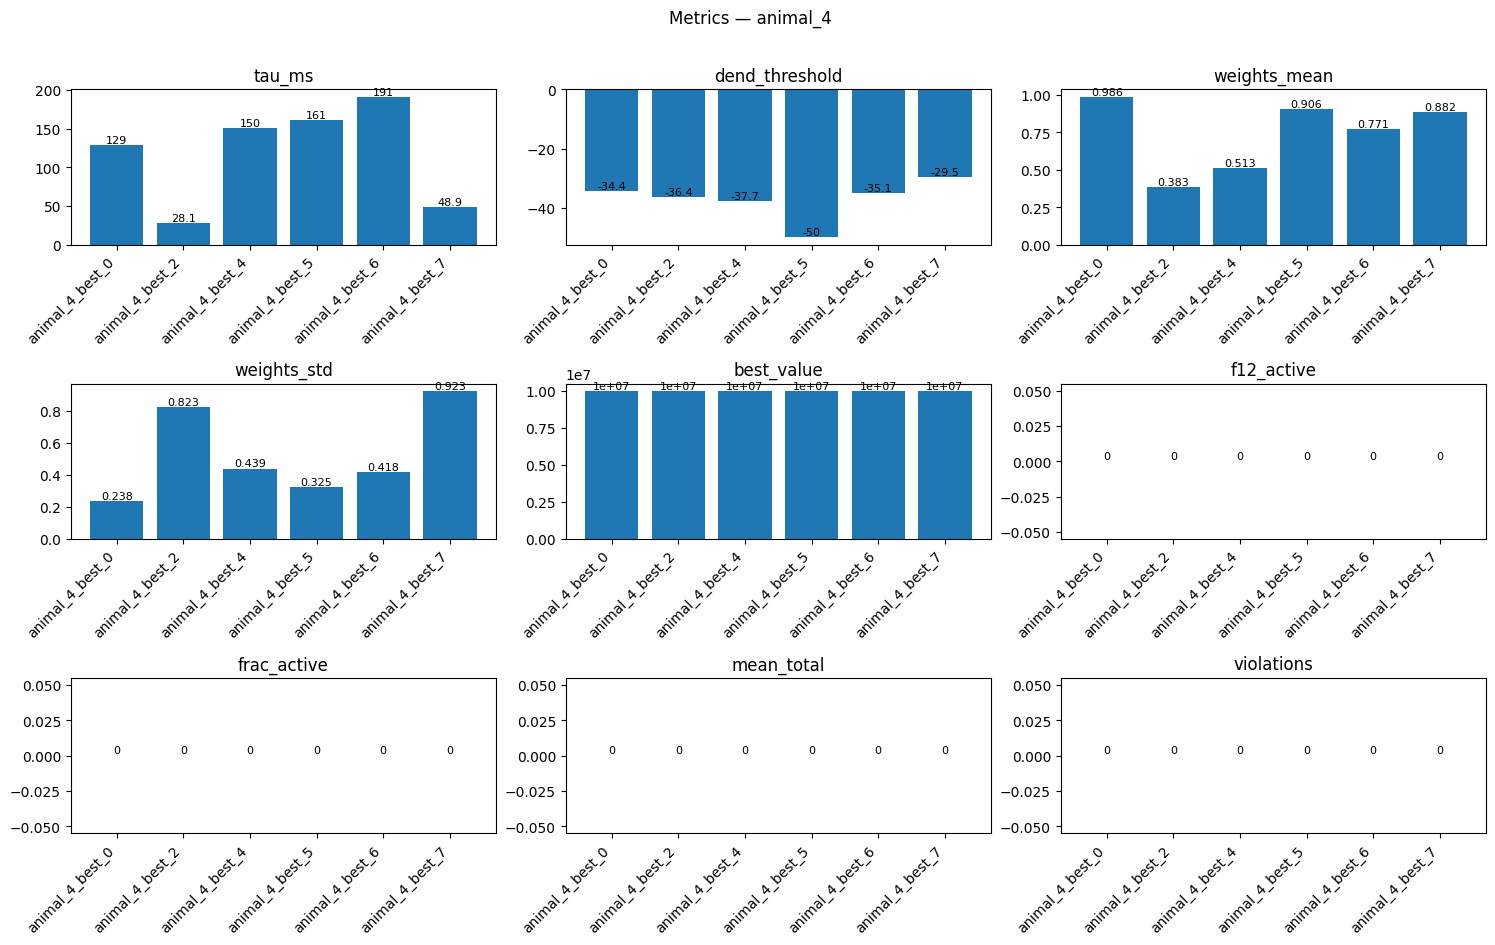

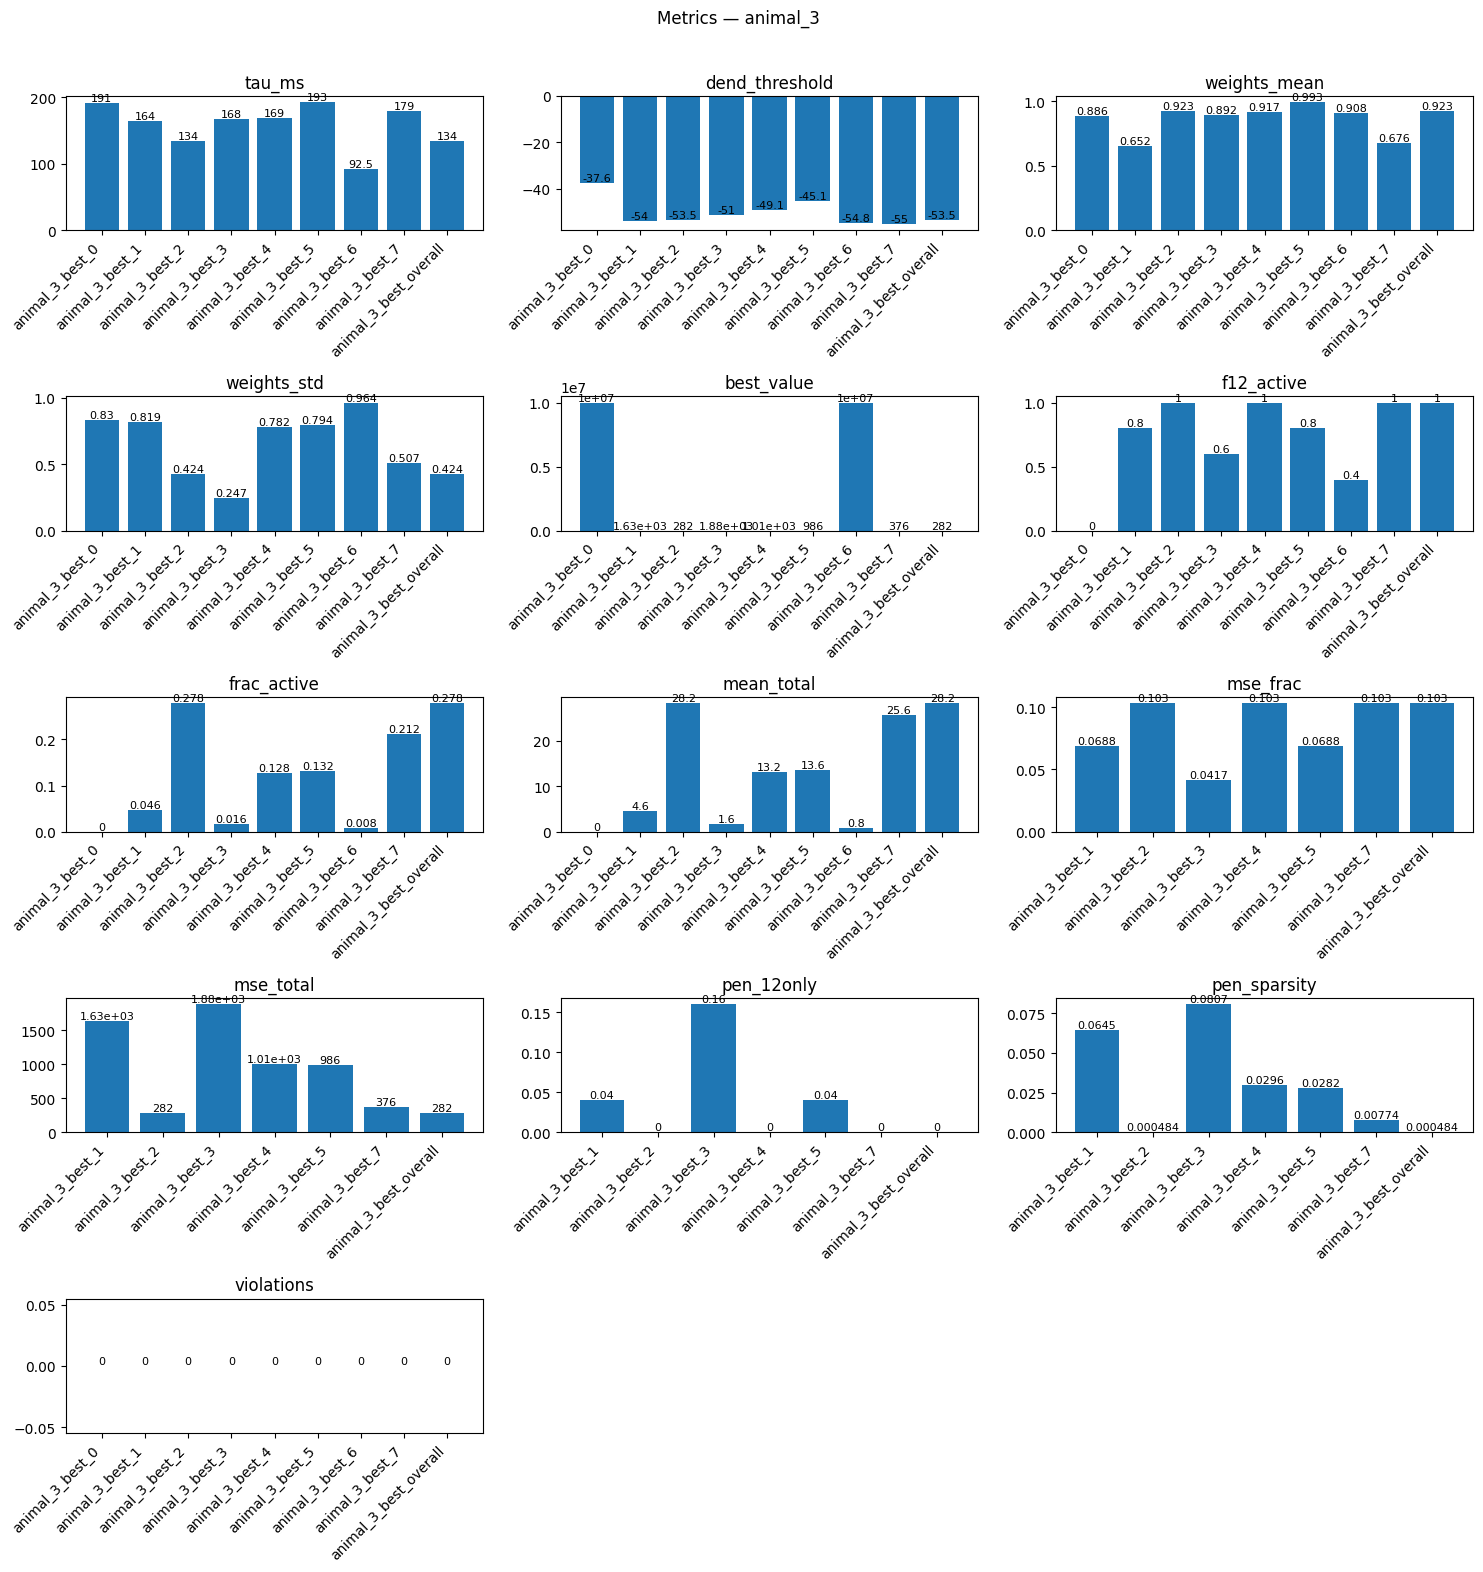

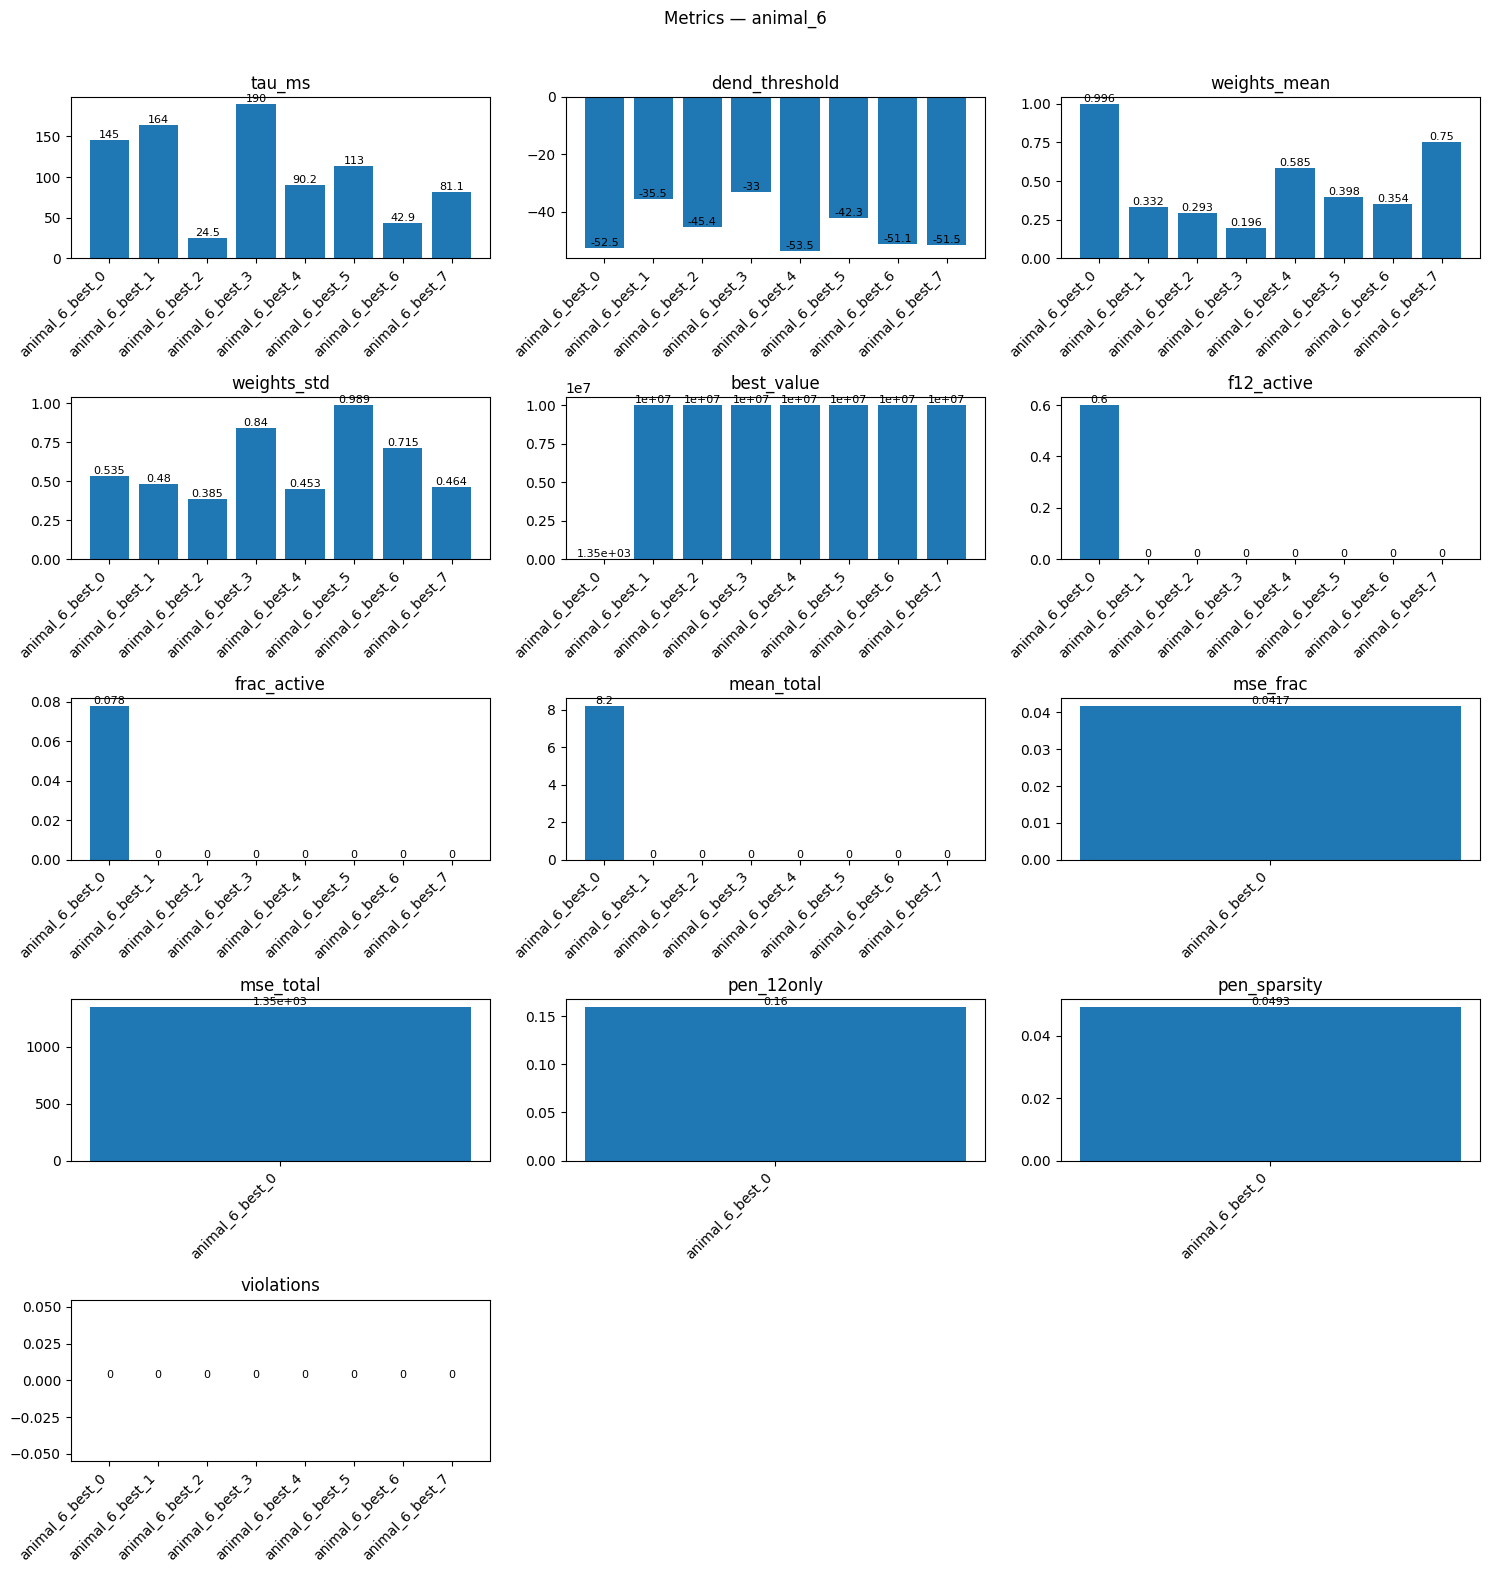

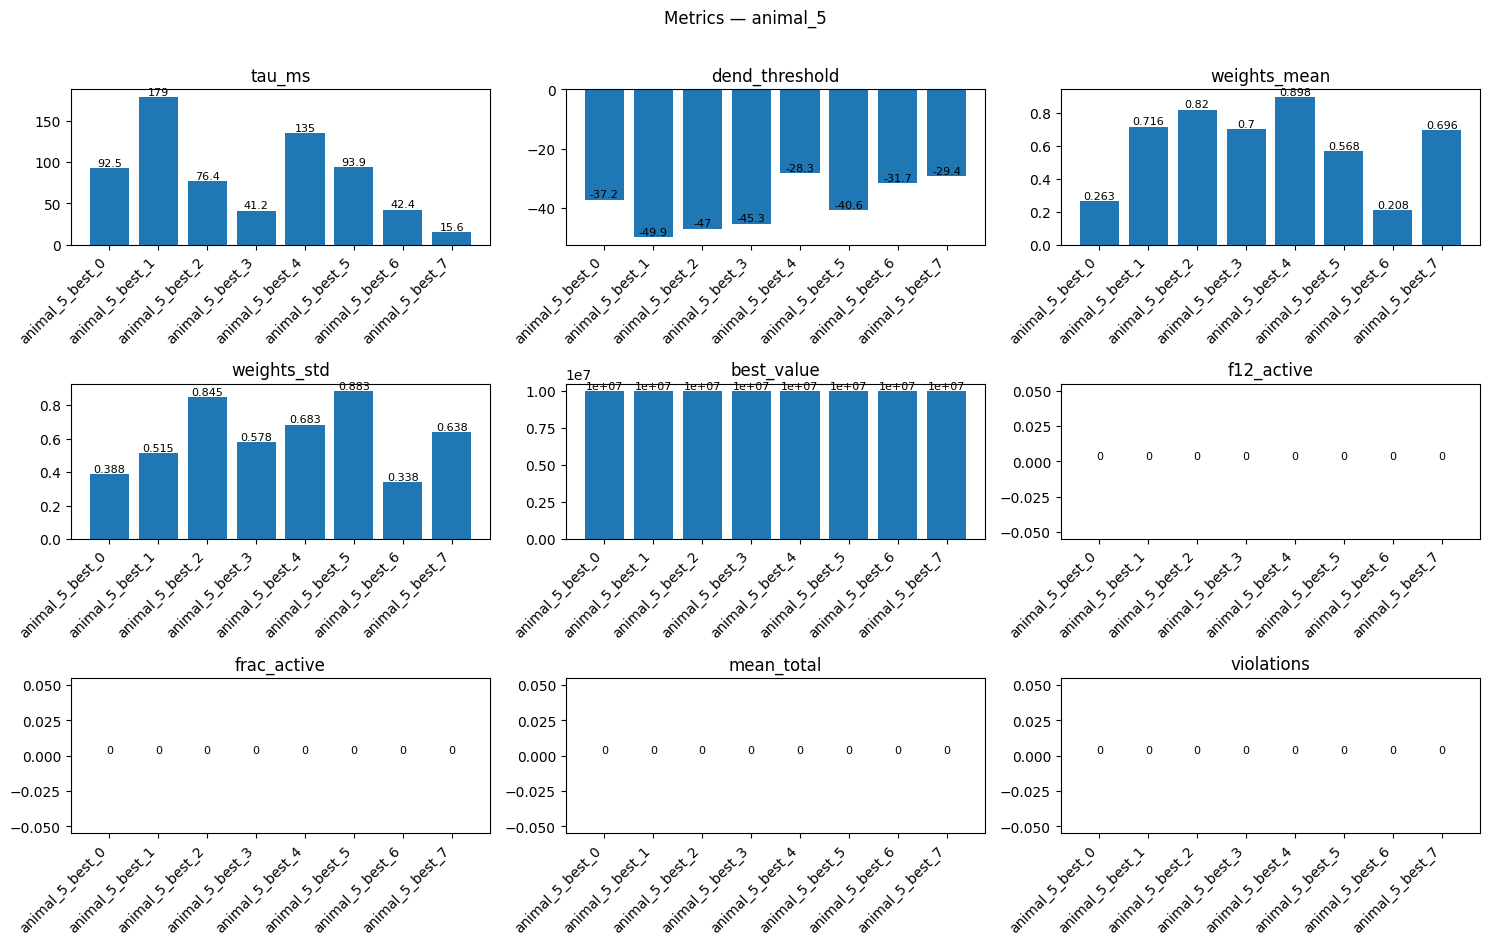

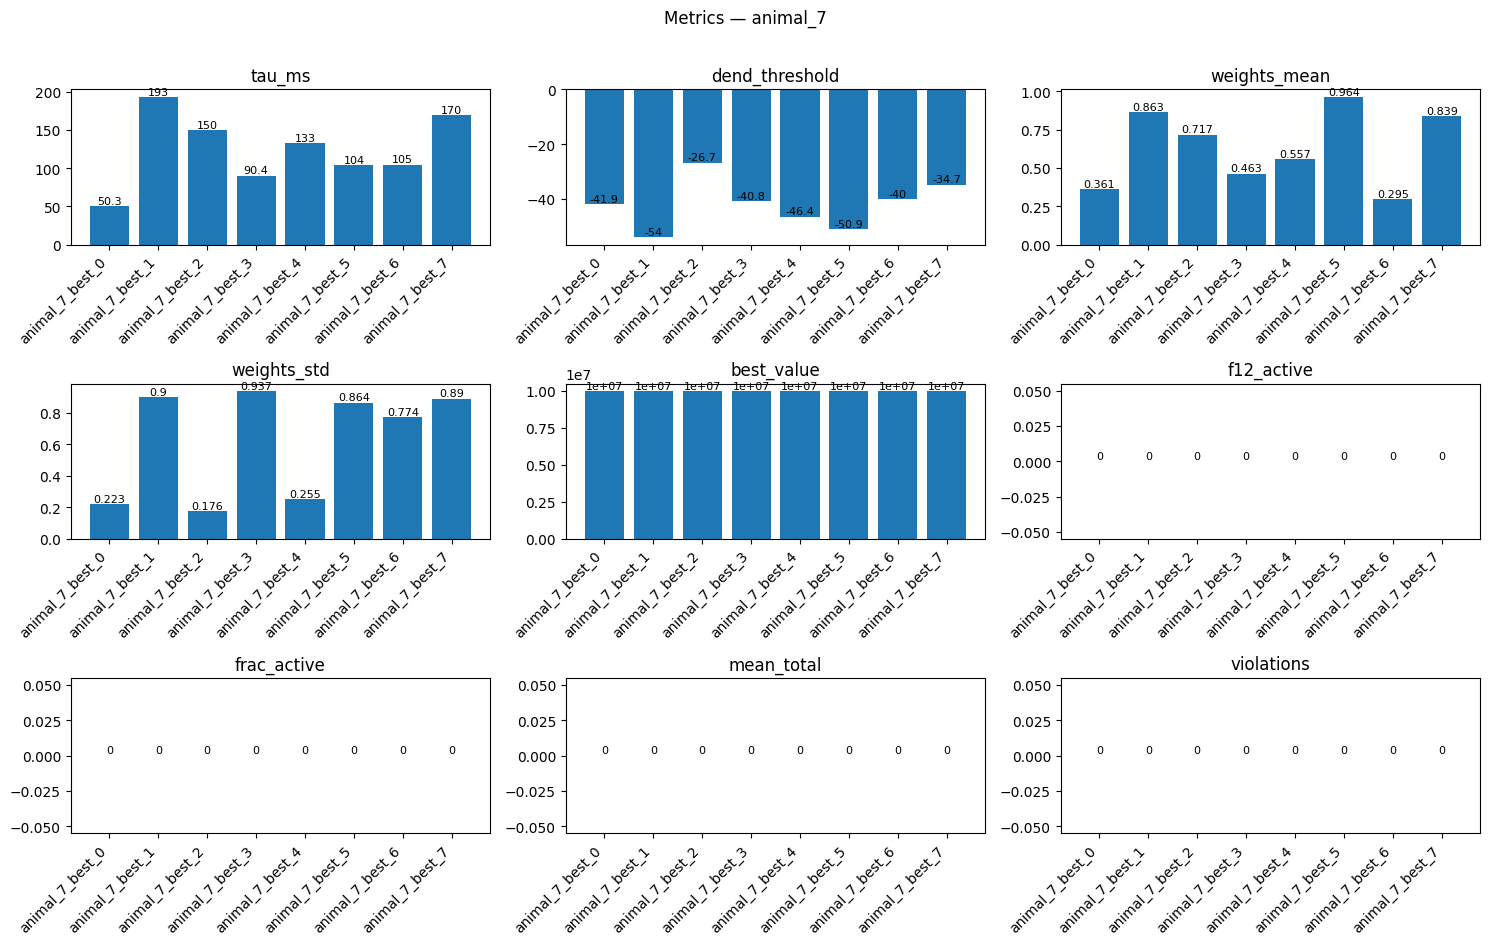

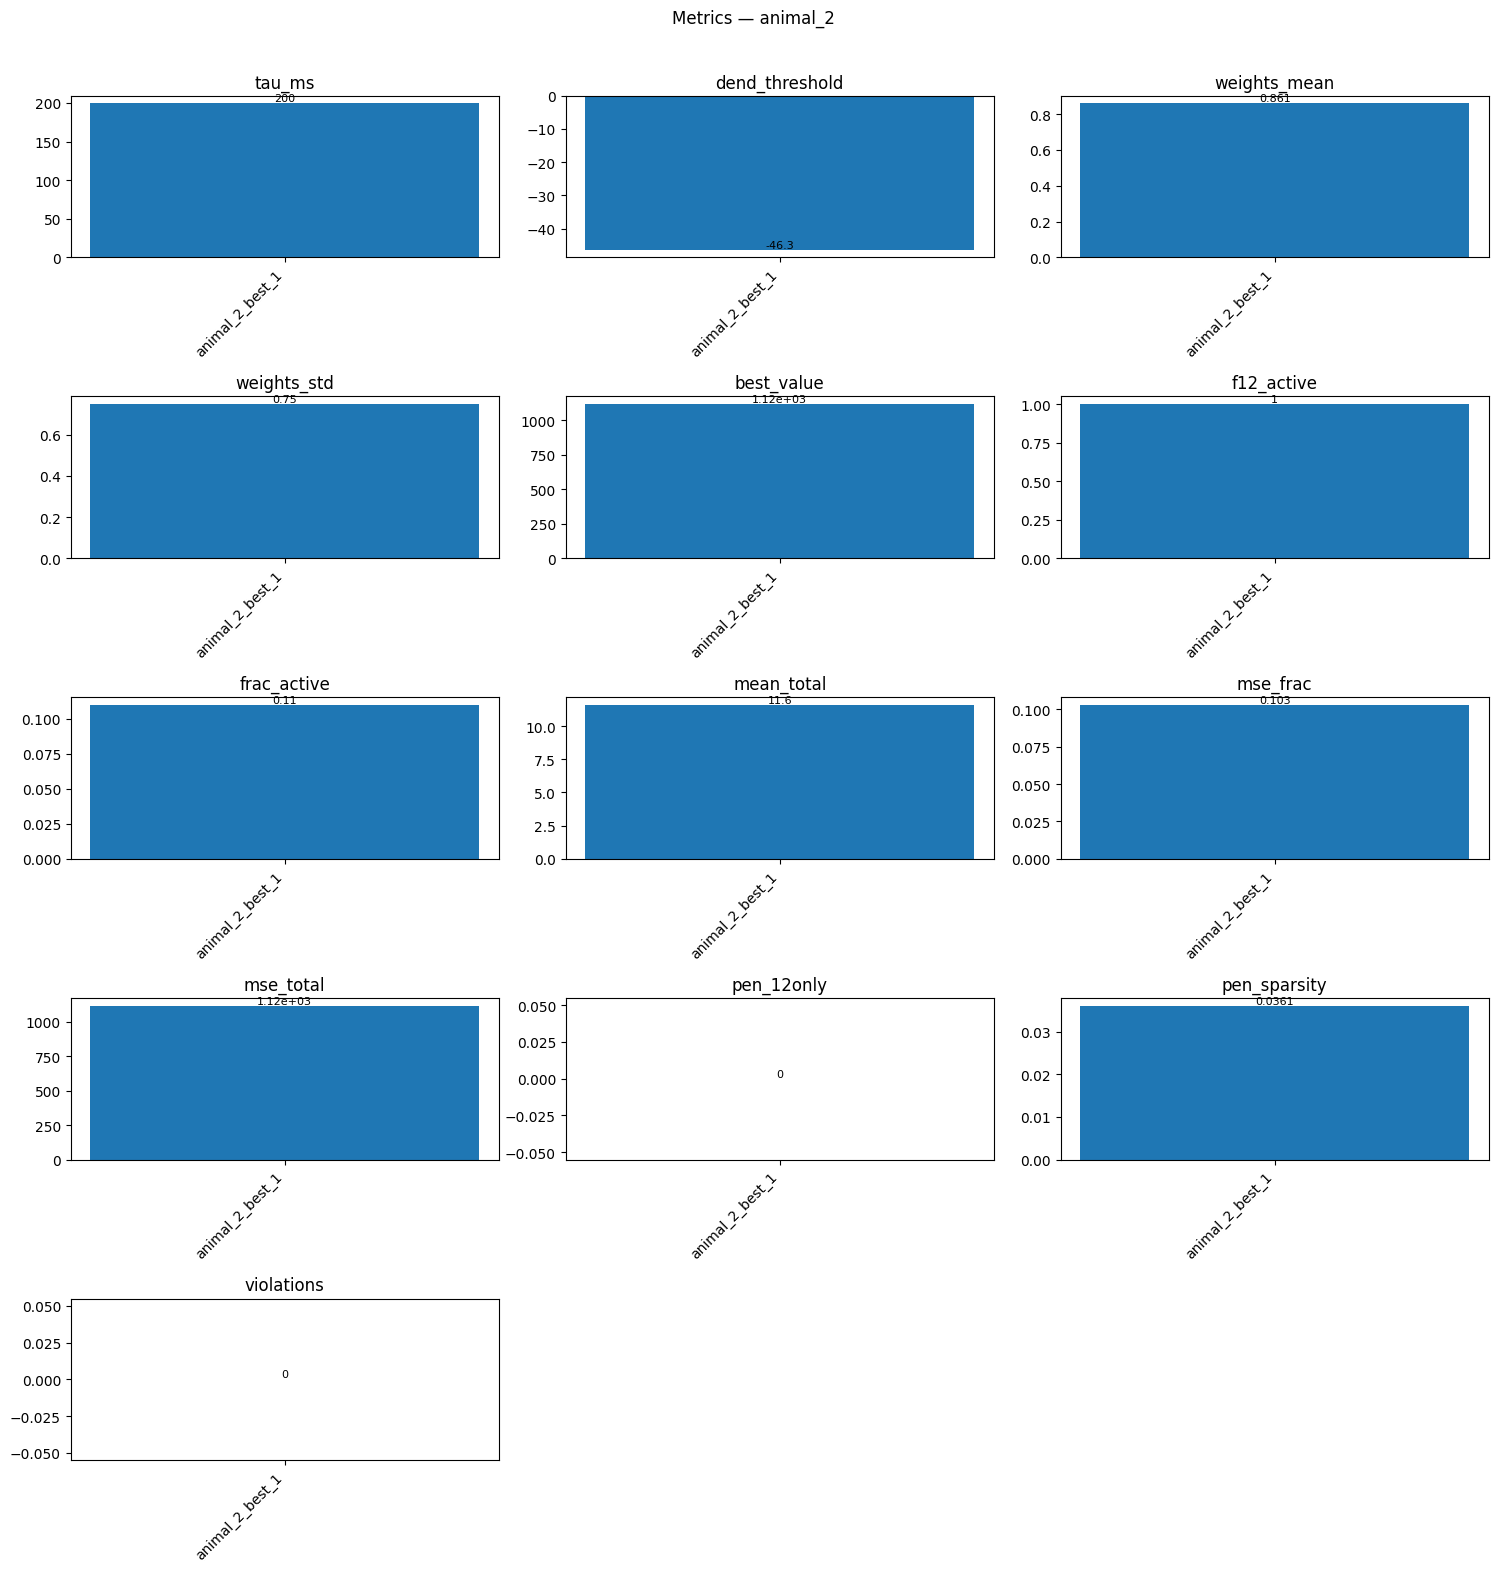

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import math

def plot_pickled_metrics(pickled_data: dict, title: str | None = None, sort_labels: bool = True):
    """
    pickled_data: {filename.pkl -> payload dict}
    payload may be {"best_params": {...}, "best_value": ..., "best_metrics": {...}} or a flat dict.
    """
    # Build a tidy table
    rows = []
    for opt_key, payload in pickled_data.items():
        label = Path(opt_key).stem
        params  = payload.get("best_params", payload) or {}
        metrics = payload.get("best_metrics", {}) or {}

        rows.append({
            "label": label,
            "tau_ms": params.get("tau_ms"),
            "dend_threshold": params.get("dend_threshold"),
            "weights_mean": params.get("weights_mean"),
            "weights_std": params.get("weights_std"),
            "best_value": payload.get("best_value"),
            "f12_active": metrics.get("f12_active"),
            "frac_active": metrics.get("frac_active"),
            "mean_total": metrics.get("mean_total"),
            "mse_frac": metrics.get("mse_frac"),
            "mse_total": metrics.get("mse_total"),
            "pen_12only": metrics.get("pen_12only"),
            "pen_sparsity": metrics.get("pen_sparsity"),
            "violations": metrics.get("violations"),
        })

    if not rows:
        print("[warn] no rows to plot")
        return

    df = pd.DataFrame(rows).set_index("label")
    if sort_labels:
        df = df.sort_index()

    cols_to_plot = [
        "tau_ms", "dend_threshold", "weights_mean", "weights_std",
        "best_value", "f12_active", "frac_active", "mean_total",
        "mse_frac", "mse_total", "pen_12only", "pen_sparsity", "violations"
    ]
    valid_cols = [c for c in cols_to_plot if c in df.columns and df[c].notna().any()]
    n = len(valid_cols)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.2*nrows), squeeze=False)

    for ax, col in zip(axes.flat, valid_cols):
        series = df[col].dropna()
        x = list(range(len(series)))
        ax.bar(x, series.values)
        ax.set_title(col)
        ax.set_xticks(x)
        ax.set_xticklabels(series.index, rotation=45, ha="right")
        # annotate bars
        for i, y in enumerate(series.values):
            if pd.notna(y):
                ax.text(i, y, f"{y:.3g}", ha="center", va="bottom", fontsize=8)

    # remove unused axes
    for ax in axes.flat[len(valid_cols):]:
        fig.delaxes(ax)

    if title:
        fig.suptitle(title)
        fig.tight_layout(rect=[0, 0, 1, 0.97])
    else:
        fig.tight_layout()

    plt.show()

# Example: one figure per animal
for animal, payloads in by_animal.items():
    plot_pickled_metrics(payloads, title=f"Metrics — {animal}")


In [9]:
by_animal["animal_3"]

{'animal_3_best_2.pkl': {'best_params': {'tau_ms': 133.63175441372994,
   'dend_threshold': -53.51632661472516,
   'weights_mean': 0.9229500828533879,
   'weights_std': 0.42433606320452333},
  'best_value': 282.3439689451796,
  'animal': 'animal_3',
  'best_metrics': {'f12_active': 1.0,
   'frac_active': 0.278,
   'mean_total': 28.2,
   'mse_frac': 0.1030009451795841,
   'mse_total': 282.24,
   'pen_12only': 0.0,
   'pen_sparsity': 0.00048399999999999843,
   'violations': 0.0},
  'best_trial_number': 44},
 'animal_3_best_3.pkl': {'best_params': {'tau_ms': 167.8623644835883,
   'dend_threshold': -51.04138626362193,
   'weights_mean': 0.8918737739934279,
   'weights_std': 0.24730527652050222},
  'best_value': 1883.9230607712666,
  'animal': 'animal_3',
  'best_metrics': {'f12_active': 0.6,
   'frac_active': 0.016,
   'mean_total': 1.6,
   'mse_frac': 0.04174877126654065,
   'mse_total': 1883.56,
   'pen_12only': 0.16000000000000003,
   'pen_sparsity': 0.08065599999999999,
   'violations'

In [ ]:
(GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC) = load_data_regular(file_path=fp, name="EC_GLM", new_NDNF=False)

(GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST) = load_data_regular(file_path=fp, name="SSTindivsomata_GLM", new_NDNF=False)

(GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest) = load_data_regular(file_path=fp, name="NDNF_E1A1B", new_NDNF=True)

fixed_filtered_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(filtered_factors_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_filtered_factors_dict_NDNF_newest[f"animal_{idx+1}"] = filtered_factors_dict_NDNF_newest[animal]

In [ ]:
from optuna.visualization.matplotlib import plot_parallel_coordinate
plot_parallel_coordinate(study, params=["tau_ms", "dend_threshold", "weights_mean", "weights_std"])
